**1 установка CVXOPT**


при помощи команды "pip install cvxopt" устанавливаем cvxopt


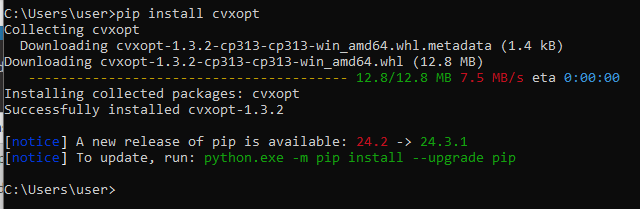

для ознакомления с библиотекой я опирался на [этот блокнот](https://colab.research.google.com/github/krutika234/BSE__IIT-PATNA_OPTIMIZATION-2021/blob/main/Tutorial_cvxopt%20.ipynb#scrollTo=PdsRSWhNxTzu) а также на документацию на официальном сайте


тестовая задача представляет собой квадратичную задачу с линейными условиями

In [ ]:
from cvxopt import matrix, solvers


Q = 2*matrix([ [1.0, 0.0], [0.0, 4.0] ])
p = matrix([-8.0, -16.0])
G = matrix([[0.0, -1.0],[1.0,0.0],[-1.0,0.0],[1.0,1.0]]).trans()  #ограничения на иксы, через запятую, в форме Gx<h
h = matrix([0.0,3,0,5])

print(G)

sol=solvers.qp(Q, p, G, h)
print(sol['x'])

[ 0.00e+00 -1.00e+00]
[ 1.00e+00  0.00e+00]
[-1.00e+00  0.00e+00]
[ 1.00e+00  1.00e+00]

     pcost       dcost       gap    pres   dres
 0: -3.0512e+01 -3.8829e+01  8e+00  0e+00  2e-01
 1: -3.0792e+01 -3.1146e+01  4e-01  2e-16  5e-03
 2: -3.0982e+01 -3.1024e+01  4e-02  1e-16  4e-04
 3: -3.0997e+01 -3.1003e+01  6e-03  2e-16  5e-17
 4: -3.1000e+01 -3.1000e+01  7e-04  2e-16  3e-17
 5: -3.1000e+01 -3.1000e+01  1e-04  2e-16  4e-17
 6: -3.1000e+01 -3.1000e+01  1e-05  2e-16  3e-17
Optimal solution found.
[ 3.00e+00]
[ 2.00e+00]



оптимальное решене лежит на пересечении линий $$ x_1 = 3  \text{,  } x_1 + x_2 \leq 0 $$

соответственно, если мы уберём прочие ограничения, решение не должно поменяться:

In [ ]:
Q = 2*matrix([ [1.0, 0.0], [0.0, 4.0] ])
p = matrix([-8.0, -16.0])
G = matrix([[1.0,0.0],[1.0,1.0]]).trans()  #ограничения на иксы, через запятую, в форме Gx<h
h = matrix([3.0,5.0])


sol=solvers.qp(Q, p, G, h)
print(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -3.1751e+01 -3.1278e+01  1e+00  4e-01  0e+00
 1: -3.1454e+01 -3.1102e+01  6e-02  7e-02  2e-17
 2: -3.0973e+01 -3.1003e+01  3e-02  8e-17  2e-16
 3: -3.0999e+01 -3.1001e+01  2e-03  0e+00  3e-17
 4: -3.1000e+01 -3.1000e+01  2e-04  0e+00  6e-18
 5: -3.1000e+01 -3.1000e+01  3e-05  0e+00  7e-17
 6: -3.1000e+01 -3.1000e+01  4e-06  0e+00  4e-17
Optimal solution found.
[ 3.00e+00]
[ 2.00e+00]



как можно видеть, так и произошло

**Линейный SVM**


Пусть N - размерность векторов х, а М - их число. Искомый вектор будет иметь размерность 2N+1 и структуру (w, кси, b). Матрица Q будет иметь единицы на первых N элементах диагонали, остальные - нули. Вектор р имеет нули на первых N местах, затем С ещё на N местах, потом ещё один ноль.

Матрица линейных ограничений G будет иметь размерность (M на 2N+1).
Её строка с номером i будет иметь вид - (x_i(1) × y_i , x_i(2) × y_i, ...,-1, ...,y_i)

вектор h представляет собой M минус единичек


In [77]:
import numpy as np

C = 0

def trainnn(X, y):
  #считаем, что Х это набор из M векторов, каждый длинны N
  Data = np.array(X)
  M , N = np.shape(Data)
  a = np.ndarray((M,2*N+1))
  for i in range(M):
    temp1 = y[i]*Data[i]
    temp2 = np.ones(N)
    temp3 = y[i]*np.ones(1)
    temp = np.concatenate((temp1,temp2,temp3))
    a[i] = - temp


  Q = 2*matrix(np.diag(np.concatenate((np.ones(N), np.zeros(N+1)))))
  p = matrix(C*np.concatenate((np.zeros(N), np.ones(N), np.zeros(1))))
  G = matrix(a) #ограничения на иксы, через запятую, в форме Gx<h
  h = matrix(-1*np.ones(M))

  '''


  Q1 = 2*matrix(np.diag(np.concatenate((np.ones(N), np.zeros(N+1)))))
  p1= matrix(C*np.concatenate((np.zeros(N), np.ones(N), np.zeros(1))))
  G1 = matrix(a) #ограничения на иксы, через запятую, в форме Gx<h
  h1 = matrix(-1*np.ones(M))
  '''

  print(Q, p, G, h)

  sol=solvers.qp(Q, p, G, h, kktsolver="chol")
  print(sol['x'])
  return p
X = [[1,2],[3,4]]
print(trainnn(X, [1,-1]) )



[ 2.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00]
[ 0.00e+00  2.00e+00  0.00e+00  0.00e+00  0.00e+00]
[ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00]
[ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00]
[ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00]
 [ 0.00e+00]
[ 0.00e+00]
[ 0.00e+00]
[ 0.00e+00]
[ 0.00e+00]
 [-1.00e+00 -2.00e+00 -1.00e+00 -1.00e+00 -1.00e+00]
[ 3.00e+00  4.00e+00 -1.00e+00 -1.00e+00  1.00e+00]
 [-1.00e+00]
[-1.00e+00]



ValueError: Rank(A) < p or Rank([P; A; G]) < n

я столкнулся со следующей ошибкой: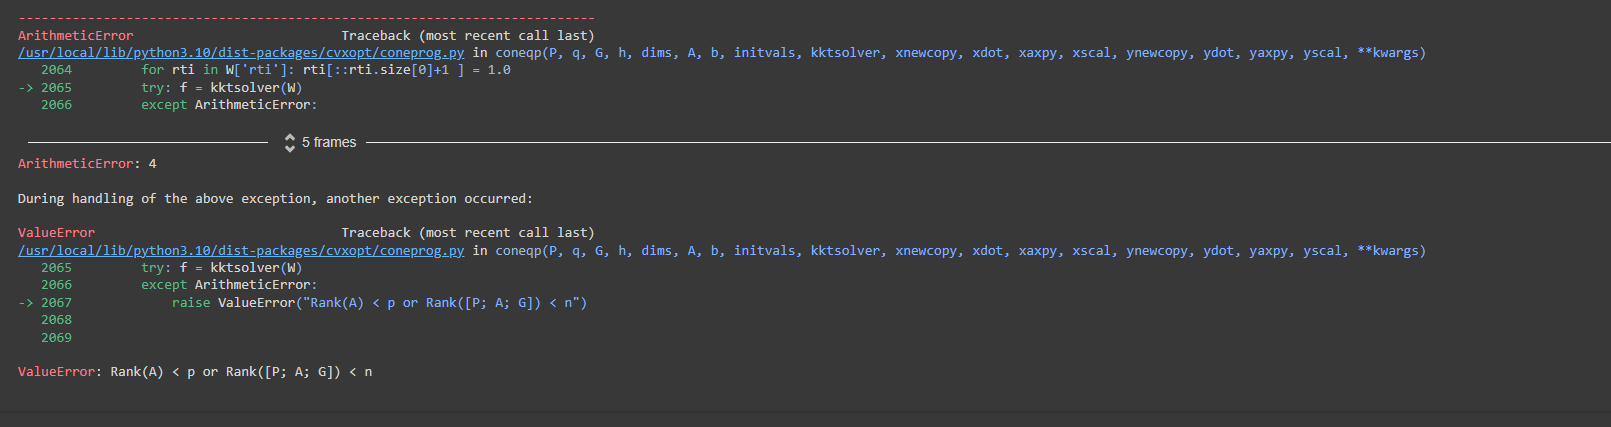 видимо, я некорректно перевёл задачу на язык квадратичного програмирования

после долгих раздумий я решил стянуть код [остюда](https://pythonprogramming.net/soft-margin-kernel-cvxopt-svm-machine-learning-tutorial/)    
я пытался адаптировать сначала под свой код, однако потом быстро сдался

In [122]:
import numpy as np
from numpy import linalg
import cvxopt
import cvxopt.solvers

sigma = 5.0
p = 3.0
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x, y):
    return (1 + np.dot(x, y)) ** p

def gaussian_kernel(x, y):
    return np.exp(-linalg.norm(x-y)**2 / (2 * (sigma ** 2)))

class SVM(object):

    def __init__(self, kernel=linear_kernel, C=None):
        self.kernel = kernel
        self.C = C
        if self.C is not None: self.C = float(self.C)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Gram matrix
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i,j] = self.kernel(X[i], X[j])

        P = cvxopt.matrix(np.outer(y,y) * K)        #вот этот шаг у меня вообще другой был
        q = cvxopt.matrix(np.ones(n_samples) * -1)
        A = cvxopt.matrix(y, (1,n_samples))
        b = cvxopt.matrix(0.0)

        if self.C is None:
            G = cvxopt.matrix(np.diag(np.ones(n_samples) * -1))
            h = cvxopt.matrix(np.zeros(n_samples))
        else:
            tmp1 = np.diag(np.ones(n_samples) * -1)
            tmp2 = np.identity(n_samples)
            G = cvxopt.matrix(np.vstack((tmp1, tmp2)))
            tmp1 = np.zeros(n_samples)
            tmp2 = np.ones(n_samples) * self.C
            h = cvxopt.matrix(np.hstack((tmp1, tmp2)))

        # solve QP problem
        solution = cvxopt.solvers.qp(P, q, G, h, A, b)

        # Lagrange multipliers
        a = np.ravel(solution['x'])

        # Support vectors have non zero lagrange multipliers
        sv = a > 1e-5
        ind = np.arange(len(a))[sv]
        self.a = a[sv]
        self.sv = X[sv]
        self.sv_y = y[sv]
        print("%d support vectors out of %d points" % (len(self.a), n_samples))

        # Intercept
        self.b = 0
        for n in range(len(self.a)):
            self.b += self.sv_y[n]
            self.b -= np.sum(self.a * self.sv_y * K[ind[n],sv])
        self.b /= len(self.a)

        # Weight vector
        if self.kernel == linear_kernel:
            self.w = np.zeros(n_features)
            for n in range(len(self.a)):
                self.w += self.a[n] * self.sv_y[n] * self.sv[n]
        else:
            self.w = None

    def project(self, X):
        if self.w is not None:
            return np.dot(X, self.w) + self.b
        else:
            y_predict = np.zeros(len(X))
            for i in range(len(X)):
                s = 0
                for a, sv_y, sv in zip(self.a, self.sv_y, self.sv):
                    s += a * sv_y * self.kernel(X[i], sv)
                y_predict[i] = s
            return y_predict + self.b

    def predict(self, X):
        return np.sign(self.project(X))


if __name__ == "__main__":
    import pylab as pl

    def gen_lin_separable_data():
        # generate training data in the 2-d case
        mean1 = np.array([0, 2])
        mean2 = np.array([2, 0])
        cov = np.array([[0.8, 0.6], [0.6, 0.8]])
        X1 = np.random.multivariate_normal(mean1, cov, 100)
        y1 = np.ones(len(X1))
        X2 = np.random.multivariate_normal(mean2, cov, 100)
        y2 = np.ones(len(X2)) * -1
        return X1, y1, X2, y2

    def gen_non_lin_separable_data():
        mean1 = [-1, 2]
        mean2 = [1, -1]
        mean3 = [4, -4]
        mean4 = [-4, 4]
        cov = [[1.0,0.8], [0.8, 1.0]]
        X1 = np.random.multivariate_normal(mean1, cov, 50)
        X1 = np.vstack((X1, np.random.multivariate_normal(mean3, cov, 50)))
        y1 = np.ones(len(X1))
        X2 = np.random.multivariate_normal(mean2, cov, 50)
        X2 = np.vstack((X2, np.random.multivariate_normal(mean4, cov, 50)))
        y2 = np.ones(len(X2)) * -1

        return X1, y1, X2, y2

    def gen_lin_separable_overlap_data():
        # generate training data in the 2-d case
        mean1 = np.array([0, 2])
        mean2 = np.array([2, 0])
        cov = np.array([[1.5, 1.0], [1.0, 1.5]])
        X1 = np.random.multivariate_normal(mean1, cov, 100)
        y1 = np.ones(len(X1))
        X2 = np.random.multivariate_normal(mean2, cov, 100)
        y2 = np.ones(len(X2)) * -1

        return X1, y1, X2, y2

    def split_train(X1, y1, X2, y2):
        X1_train = X1[:90]
        y1_train = y1[:90]
        X2_train = X2[:90]
        y2_train = y2[:90]
        X_train = np.vstack((X1_train, X2_train))
        y_train = np.hstack((y1_train, y2_train))
        return X_train, y_train

    def split_test(X1, y1, X2, y2):
        X1_test = X1[90:]
        y1_test = y1[90:]
        X2_test = X2[90:]
        y2_test = y2[90:]
        X_test = np.vstack((X1_test, X2_test))
        y_test = np.hstack((y1_test, y2_test))
        return X_test, y_test

    def plot_margin(X1_train, X2_train, clf):
        def f(x, w, b, c=0):
            # given x, return y such that [x,y] in on the line
            # w.x + b = c
            return (-w[0] * x - b + c) / w[1]

        pl.plot(X1_train[:,0], X1_train[:,1], "ro")
        pl.plot(X2_train[:,0], X2_train[:,1], "bo")
        pl.scatter(clf.sv[:,0], clf.sv[:,1], s=100, c="g")

        # w.x + b = 0
        a0 = -4; a1 = f(a0, clf.w, clf.b)
        b0 = 4; b1 = f(b0, clf.w, clf.b)
        pl.plot([a0,b0], [a1,b1], "k")

        # w.x + b = 1
        a0 = -4; a1 = f(a0, clf.w, clf.b, 1)
        b0 = 4; b1 = f(b0, clf.w, clf.b, 1)
        pl.plot([a0,b0], [a1,b1], "k--")

        # w.x + b = -1
        a0 = -4; a1 = f(a0, clf.w, clf.b, -1)
        b0 = 4; b1 = f(b0, clf.w, clf.b, -1)
        pl.plot([a0,b0], [a1,b1], "k--")

        pl.axis("tight")
        pl.show()

    def plot_contour(X1_train, X2_train, clf):
        pl.plot(X1_train[:,0], X1_train[:,1], "ro")
        pl.plot(X2_train[:,0], X2_train[:,1], "bo")
        pl.scatter(clf.sv[:,0], clf.sv[:,1], s=100, c="g")

        X1, X2 = np.meshgrid(np.linspace(-6,6,50), np.linspace(-6,6,50))
        X = np.array([[x1, x2] for x1, x2 in zip(np.ravel(X1), np.ravel(X2))])
        Z = clf.project(X).reshape(X1.shape)
        pl.contour(X1, X2, Z, [0.0], colors='k', linewidths=1, origin='lower')
        pl.contour(X1, X2, Z + 1, [0.0], colors='grey', linewidths=1, origin='lower')
        pl.contour(X1, X2, Z - 1, [0.0], colors='grey', linewidths=1, origin='lower')

        pl.axis("tight")
        pl.show()

    def test_linear():
        X1, y1, X2, y2 = gen_lin_separable_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM()
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_margin(X_train[y_train==1], X_train[y_train==-1], clf)

    def test_non_linear():
        X1, y1, X2, y2 = gen_non_lin_separable_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM(polynomial_kernel)
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

    def test_soft():
        X1, y1, X2, y2 = gen_lin_separable_overlap_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM(C=10.1)
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)


    #test_linear()
    #test_non_linear()
    #test_soft()

линейно разделимый случай:


     pcost       dcost       gap    pres   dres
 0: -1.8403e+01 -3.4659e+01  6e+02  2e+01  2e+00
 1: -2.1284e+01 -1.3574e+01  2e+02  7e+00  5e-01
 2: -5.3594e+01 -2.1774e+01  1e+02  4e+00  3e-01
 3: -1.5247e+01 -5.9599e+00  2e+01  7e-01  6e-02
 4: -3.8939e+00 -4.7644e+00  9e-01  4e-15  1e-14
 5: -4.3950e+00 -4.4130e+00  2e-02  3e-15  7e-15
 6: -4.4075e+00 -4.4084e+00  9e-04  3e-15  7e-15
 7: -4.4082e+00 -4.4082e+00  9e-06  1e-15  6e-15
 8: -4.4082e+00 -4.4082e+00  9e-08  1e-15  7e-15
Optimal solution found.
3 support vectors out of 180 points
20 out of 20 predictions correct


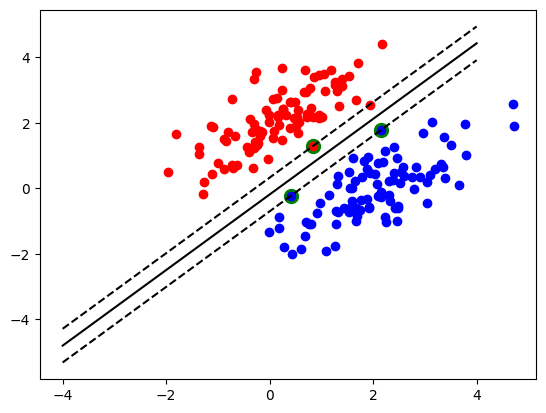

In [117]:
test_linear()

не линейно разделимый случай: (полиномное ядро)

     pcost       dcost       gap    pres   dres
 0: -4.2068e+01 -9.5695e+01  1e+03  4e+01  2e+00
 1: -7.1307e+01 -7.3413e+01  6e+02  2e+01  1e+00
 2: -1.8318e+01 -5.0708e+00  2e+02  4e+00  2e-01
 3: -6.7123e-01 -5.9772e-01  7e+00  2e-01  9e-03
 4: -1.4316e-01 -4.5487e-01  2e+00  4e-02  2e-03
 5: -8.6206e-02 -3.4117e-01  9e-01  2e-02  1e-03
 6: -1.0424e-01 -2.3561e-01  4e-01  5e-03  3e-04
 7: -1.1438e-01 -1.8546e-01  2e-01  2e-03  1e-04
 8: -1.1818e-01 -1.8498e-01  1e-01  1e-03  7e-05
 9: -1.3134e-01 -1.6770e-01  4e-02  7e-17  9e-14
10: -1.4945e-01 -1.6244e-01  1e-02  4e-17  6e-14
11: -1.5747e-01 -1.6006e-01  3e-03  9e-17  7e-14
12: -1.5922e-01 -1.5959e-01  4e-04  7e-17  7e-14
13: -1.5954e-01 -1.5954e-01  5e-06  3e-18  8e-14
14: -1.5954e-01 -1.5954e-01  5e-08  1e-16  7e-14
Optimal solution found.
9 support vectors out of 180 points
20 out of 20 predictions correct


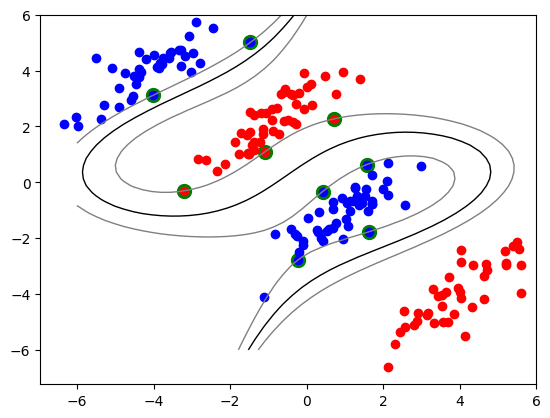

In [96]:
test_non_linear()

плохо разделимый случай:

     pcost       dcost       gap    pres   dres
 0: -1.4041e+02 -7.8568e+02  6e+03  5e+00  3e-12
 1: -8.6242e+01 -6.3843e+02  1e+03  6e-01  4e-12
 2: -7.6029e+01 -2.6533e+02  2e+02  4e-02  2e-12
 3: -8.6743e+01 -1.2165e+02  4e+01  6e-03  2e-12
 4: -9.6051e+01 -1.0633e+02  1e+01  1e-03  2e-12
 5: -9.9470e+01 -1.0217e+02  3e+00  2e-04  3e-12
 6: -1.0018e+02 -1.0112e+02  9e-01  5e-05  3e-12
 7: -1.0048e+02 -1.0069e+02  2e-01  1e-05  2e-12
 8: -1.0056e+02 -1.0058e+02  3e-02  1e-06  2e-12
 9: -1.0057e+02 -1.0057e+02  5e-03  1e-07  2e-12
10: -1.0057e+02 -1.0057e+02  8e-04  2e-08  3e-12
11: -1.0057e+02 -1.0057e+02  1e-05  2e-10  3e-12
Optimal solution found.
108 support vectors out of 180 points
11 out of 20 predictions correct


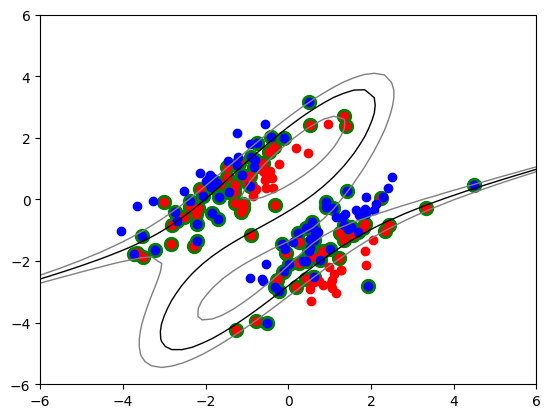

In [98]:
def gen_non_lin_separable_data():
        mean1 = [-1, .5]
        mean2 = [1, -1]
        mean3 = [1, -2]
        mean4 = [-2, .3]
        cov = [[1.0,0.8], [0.8, 1.0]]
        X1 = np.random.multivariate_normal(mean1, cov, 50)
        X1 = np.vstack((X1, np.random.multivariate_normal(mean3, cov, 50)))
        y1 = np.ones(len(X1))
        X2 = np.random.multivariate_normal(mean2, cov, 50)
        X2 = np.vstack((X2, np.random.multivariate_normal(mean4, cov, 50)))
        y2 = np.ones(len(X2)) * -1

        return X1, y1, X2, y2

def test_non_linear():
        X1, y1, X2, y2 = gen_non_lin_separable_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM(polynomial_kernel, C=1)
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

test_non_linear()

играемся с С:



     pcost       dcost       gap    pres   dres
 0: -2.9950e+01 -3.2519e+02  2e+03  2e+00  3e-14
 1: -1.8544e+01 -1.6735e+02  3e+02  3e-01  3e-14
 2: -1.0078e+01 -3.1124e+01  3e+01  3e-02  2e-14
 3: -9.1214e+00 -1.3292e+01  6e+00  5e-03  2e-14
 4: -9.6646e+00 -1.0571e+01  1e+00  7e-04  2e-14
 5: -9.8284e+00 -1.0043e+01  2e-01  1e-04  1e-14
 6: -9.9029e+00 -9.9113e+00  9e-03  3e-06  1e-14
 7: -9.9060e+00 -9.9062e+00  2e-04  5e-08  1e-14
 8: -9.9061e+00 -9.9061e+00  2e-06  5e-10  1e-14
Optimal solution found.
14 support vectors out of 180 points
20 out of 20 predictions correct


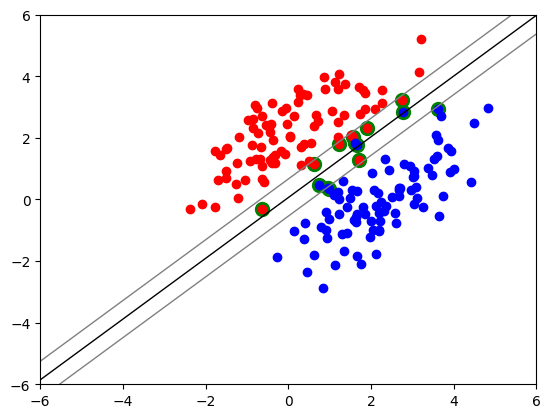

In [101]:
def test_soft(Const):
        X1, y1, X2, y2 = gen_lin_separable_overlap_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM(C=Const)
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

test_soft(1)

     pcost       dcost       gap    pres   dres
 0: -1.8677e+02 -1.3112e+04  4e+04  9e-01  1e-13
 1: -7.3946e+01 -3.6070e+03  5e+03  8e-02  1e-13
 2: -1.1706e+01 -5.1884e+02  7e+02  1e-02  9e-14
 3: -4.3799e+01 -1.0732e+02  6e+01  2e-14  6e-14
 4: -5.1142e+01 -1.0893e+02  6e+01  4e-15  7e-14
 5: -5.3793e+01 -1.0553e+02  5e+01  9e-15  8e-14
 6: -6.4564e+01 -1.0073e+02  4e+01  3e-14  7e-14
 7: -6.4372e+01 -9.9302e+01  3e+01  4e-15  6e-14
 8: -7.0608e+01 -9.2244e+01  2e+01  1e-14  7e-14
 9: -6.9236e+01 -9.1136e+01  2e+01  3e-15  7e-14
10: -7.3304e+01 -8.6736e+01  1e+01  6e-15  8e-14
11: -7.3939e+01 -8.5808e+01  1e+01  1e-14  6e-14
12: -7.6214e+01 -8.3198e+01  7e+00  2e-14  8e-14
13: -7.7429e+01 -8.1495e+01  4e+00  7e-15  9e-14
14: -7.8171e+01 -8.0665e+01  2e+00  6e-15  9e-14
15: -7.9230e+01 -7.9376e+01  1e-01  3e-14  1e-13
16: -7.9290e+01 -7.9294e+01  4e-03  4e-15  8e-14
17: -7.9292e+01 -7.9292e+01  4e-05  1e-14  1e-13
Optimal solution found.
11 support vectors out of 180 points
20 out of

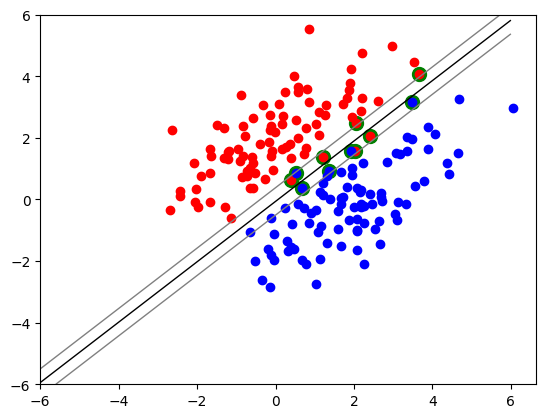

In [103]:
test_soft(10)

     pcost       dcost       gap    pres   dres
 0: -2.4562e+01 -9.2023e+01  1e+03  7e+00  2e-14
 1: -9.8213e+00 -7.1754e+01  1e+02  7e-01  1e-14
 2: -5.9701e+00 -2.4521e+01  3e+01  1e-01  7e-15
 3: -5.1713e+00 -8.1282e+00  4e+00  1e-02  5e-15
 4: -5.4882e+00 -6.6648e+00  1e+00  5e-03  5e-15
 5: -5.6908e+00 -5.8474e+00  2e-01  3e-04  6e-15
 6: -5.7307e+00 -5.7840e+00  6e-02  9e-05  5e-15
 7: -5.7479e+00 -5.7619e+00  1e-02  1e-05  6e-15
 8: -5.7540e+00 -5.7543e+00  2e-04  2e-07  7e-15
 9: -5.7541e+00 -5.7541e+00  2e-06  2e-09  6e-15
Optimal solution found.
25 support vectors out of 180 points
20 out of 20 predictions correct


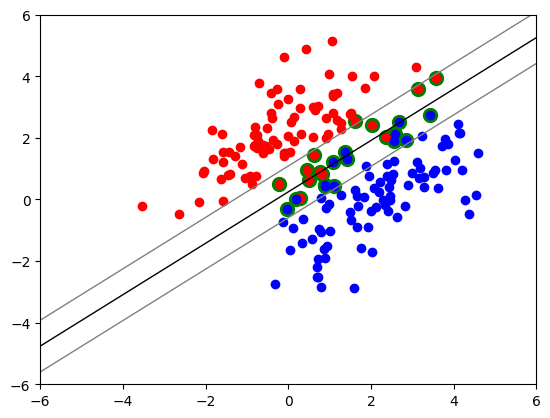

In [107]:
test_soft(.3)

вывод: меньше С - большее количество опорных венкторов

Тестируем различные ядра:


In [130]:
def gen_non_lin_separable_data():
        mean1 = [-1, .7]
        mean2 = [1.2, -1]
        mean3 = [4, -1]
        mean4 = [-1, 4]
        cov = [[1.0,0.8], [0.8, 1.0]]
        X1 = np.random.multivariate_normal(mean1, cov, 50)
        X1 = np.vstack((X1, np.random.multivariate_normal(mean3, cov, 50)))
        y1 = np.ones(len(X1))
        X2 = np.random.multivariate_normal(mean2, cov, 50)
        X2 = np.vstack((X2, np.random.multivariate_normal(mean4, cov, 50)))
        y2 = np.ones(len(X2)) * -1

        return X1, y1, X2, y2



def test_non_linear(kern,Const):
        X1, y1, X2, y2 = gen_non_lin_separable_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM(kern, Const)
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)



     pcost       dcost       gap    pres   dres
 0: -1.6143e+02 -4.2300e+02  1e+03  2e+00  7e-14
 1: -1.1805e+02 -2.8313e+02  2e+02  1e-14  8e-14
 2: -1.3241e+02 -1.5764e+02  3e+01  2e-14  7e-14
 3: -1.3982e+02 -1.4587e+02  6e+00  1e-14  8e-14
 4: -1.4099e+02 -1.4422e+02  3e+00  2e-14  6e-14
 5: -1.4174e+02 -1.4318e+02  1e+00  3e-14  6e-14
 6: -1.4213e+02 -1.4270e+02  6e-01  3e-14  7e-14
 7: -1.4230e+02 -1.4250e+02  2e-01  1e-14  8e-14
 8: -1.4239e+02 -1.4240e+02  1e-02  8e-15  8e-14
 9: -1.4239e+02 -1.4239e+02  5e-04  8e-15  8e-14
10: -1.4239e+02 -1.4239e+02  5e-06  3e-14  8e-14
Optimal solution found.
145 support vectors out of 180 points
20 out of 20 predictions correct


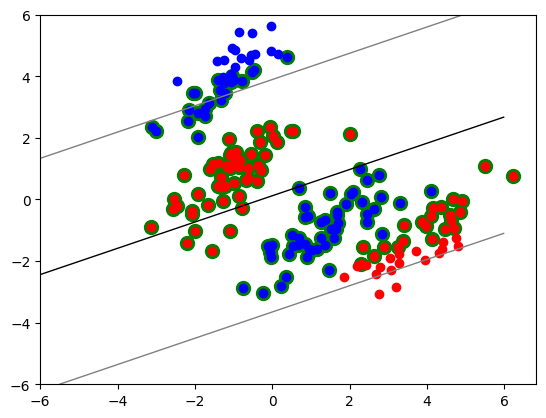

In [132]:
# линейное ядро (всё плохо)
C=1
test_non_linear(linear_kernel, C)

     pcost       dcost       gap    pres   dres
 0: -5.9376e+01 -5.6265e+02  4e+03  4e+00  1e-11
 1: -3.3535e+01 -3.9438e+02  8e+02  7e-01  1e-11
 2: -1.6635e+01 -1.7197e+02  3e+02  2e-01  4e-12
 3: -7.5847e+00 -6.4462e+01  1e+02  8e-02  2e-12
 4: -3.5071e+00 -2.7456e+01  4e+01  3e-02  1e-12
 5: -1.9932e+00 -1.8895e+01  3e+01  1e-02  8e-13
 6: -1.5391e+00 -1.0971e+01  1e+01  6e-03  4e-13
 7: -1.4580e+00 -7.8411e+00  8e+00  3e-03  3e-13
 8: -1.7834e+00 -4.2540e+00  3e+00  7e-04  3e-13
 9: -2.0813e+00 -2.9318e+00  9e-01  7e-05  3e-13
10: -2.2977e+00 -2.4555e+00  2e-01  1e-05  3e-13
11: -2.3277e+00 -2.3761e+00  5e-02  8e-07  3e-13
12: -2.3484e+00 -2.3500e+00  2e-03  3e-08  3e-13
13: -2.3491e+00 -2.3491e+00  4e-05  5e-10  3e-13
14: -2.3491e+00 -2.3491e+00  1e-06  6e-12  3e-13
Optimal solution found.
12 support vectors out of 180 points
20 out of 20 predictions correct


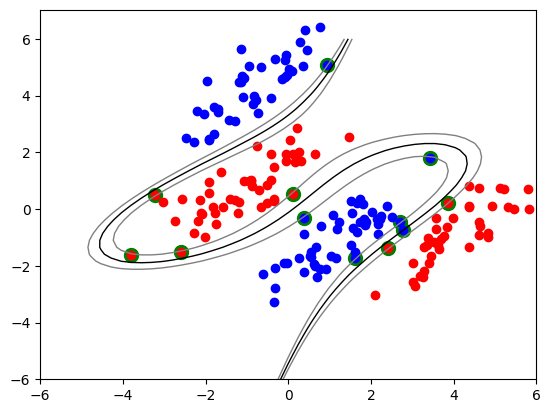

In [168]:
#играемся со степенями
p = 3
C = 1
test_non_linear(polynomial_kernel,C)

     pcost       dcost       gap    pres   dres
 0: -1.6062e+01 -2.8373e+02  1e+03  2e+00  3e-09
 1: -1.0237e+01 -1.3472e+02  2e+02  2e-01  2e-09
 2: -5.2970e+00 -5.0541e+01  7e+01  7e-02  2e-09
 3: -3.5001e+00 -1.3607e+01  1e+01  1e-02  4e-10
 4: -3.6635e+00 -9.2692e+00  8e+00  6e-03  3e-10
 5: -3.7059e+00 -7.4237e+00  5e+00  3e-03  2e-10
 6: -3.5093e+00 -5.9334e+00  4e+00  2e-03  3e-10
 7: -3.3723e+00 -5.3750e+00  3e+00  2e-03  2e-10
 8: -3.2825e+00 -5.1037e+00  3e+00  1e-03  2e-10
 9: -3.2978e+00 -4.2883e+00  2e+00  6e-04  3e-10
10: -3.2181e+00 -3.7893e+00  2e+00  5e-04  2e-10
11: -3.0822e+00 -3.3728e+00  2e+00  4e-04  2e-10
12: -2.9059e+00 -2.9852e+00  2e+00  3e-04  2e-10
13: -2.7903e+00 -2.7945e+00  2e+00  3e-04  2e-10
14: -2.4495e+00 -2.6043e+00  2e+00  2e-04  2e-10
15: -2.1806e+00 -2.3077e+00  1e+00  1e-04  1e-10
16: -1.7919e+00 -1.7968e+00  6e-01  5e-05  2e-10
17: -1.7557e+00 -1.7694e+00  6e-01  5e-05  2e-10
18: -1.6241e+00 -1.6680e+00  5e-01  3e-05  1e-10
19: -1.4518e+00 -1.53

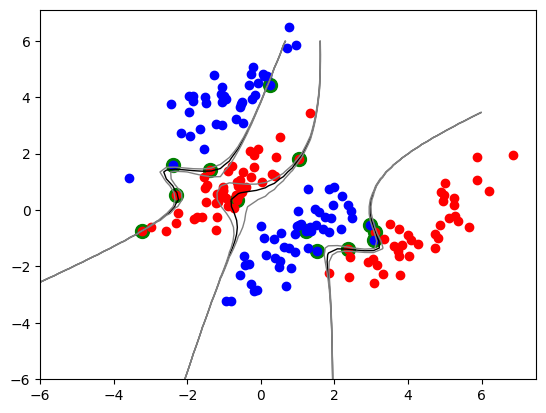

In [148]:
p = 5
C=1
test_non_linear(polynomial_kernel, C)




*   высокие степени p ведут к перепоручению
*   малые значения C сильно "расслабляют" модель



     pcost       dcost       gap    pres   dres
 0: -6.7918e+01 -2.7189e+02  2e+02  4e-15  4e-16
 1: -7.0692e+01 -8.3535e+01  1e+01  4e-16  2e-16
 2: -7.3372e+01 -7.5638e+01  2e+00  3e-15  1e-16
 3: -7.3879e+01 -7.4202e+01  3e-01  8e-15  1e-16
 4: -7.3948e+01 -7.3982e+01  3e-02  2e-14  1e-16
 5: -7.3957e+01 -7.3960e+01  4e-03  9e-16  1e-16
 6: -7.3958e+01 -7.3958e+01  4e-04  1e-14  1e-16
 7: -7.3958e+01 -7.3958e+01  4e-05  2e-14  1e-16
Optimal solution found.
177 support vectors out of 180 points
20 out of 20 predictions correct


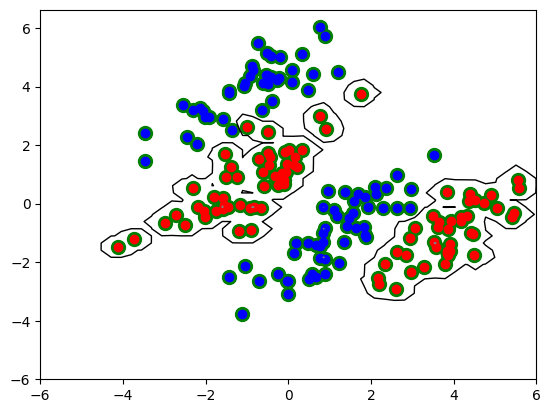

In [150]:
sigma = .1
C = 1
test_non_linear(gaussian_kernel, C)

     pcost       dcost       gap    pres   dres
 0: -1.5115e+02 -3.8974e+02  1e+03  2e+00  2e-14
 1: -1.1784e+02 -2.5628e+02  1e+02  2e-14  2e-14
 2: -1.3320e+02 -1.5205e+02  2e+01  2e-14  2e-14
 3: -1.3827e+02 -1.4175e+02  3e+00  6e-15  3e-14
 4: -1.3956e+02 -1.4027e+02  7e-01  3e-14  3e-14
 5: -1.3987e+02 -1.3998e+02  1e-01  1e-14  2e-14
 6: -1.3991e+02 -1.3993e+02  2e-02  2e-14  3e-14
 7: -1.3992e+02 -1.3992e+02  2e-03  2e-14  3e-14
 8: -1.3992e+02 -1.3992e+02  3e-05  4e-15  3e-14
Optimal solution found.
150 support vectors out of 180 points
20 out of 20 predictions correct


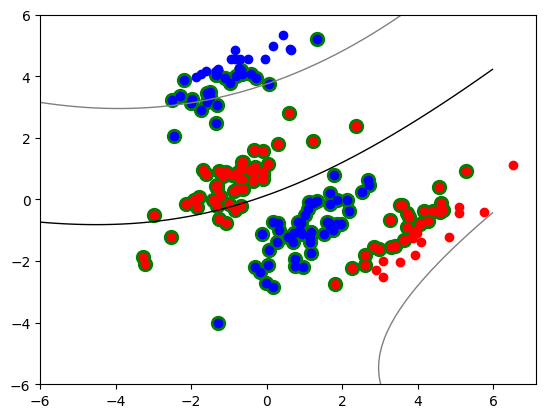

In [151]:
sigma = 10
C = 1
test_non_linear(gaussian_kernel, C)




*   малые значения сигма заставляют модель переобучиться
*   высокие делают её слишком грубой



     pcost       dcost       gap    pres   dres
 0:  7.5962e+12 -2.8020e+13  4e+13  2e-10  2e-10
 1:  1.6940e+12 -2.8999e+12  5e+12  1e-09  3e-10
 2:  2.5506e+11 -3.0517e+11  6e+11  1e-09  1e-10
 3:  3.6863e+10 -4.1812e+10  8e+10  3e-11  5e-11
 4:  5.2963e+09 -5.8818e+09  1e+10  1e-10  2e-11
 5:  7.5960e+08 -8.3828e+08  2e+09  7e-11  8e-12
 6:  1.0886e+08 -1.1990e+08  2e+08  3e-11  3e-12
 7:  1.5590e+07 -1.7180e+07  3e+07  1e-11  1e-12
 8:  2.2300e+06 -2.4654e+06  5e+06  9e-13  4e-13
 9:  3.1797e+05 -3.5484e+05  7e+05  9e-14  2e-13
10:  4.4958e+04 -5.1450e+04  1e+05  2e-13  5e-14
11:  6.2052e+03 -7.6062e+03  1e+04  4e-15  2e-14
12:  7.9205e+02 -1.1834e+03  2e+03  1e-13  8e-15
13:  6.8726e+01 -2.1055e+02  3e+02  6e-14  3e-15
14: -1.6561e+01 -5.2941e+01  4e+01  2e-14  1e-15
15: -2.3910e+01 -3.1166e+01  7e+00  8e-15  7e-16
16: -2.5256e+01 -2.6660e+01  1e+00  2e-15  6e-16
17: -2.5657e+01 -2.6042e+01  4e-01  5e-15  5e-16
18: -2.5765e+01 -2.5852e+01  9e-02  3e-15  5e-16
19: -2.5784e+01 -2.58

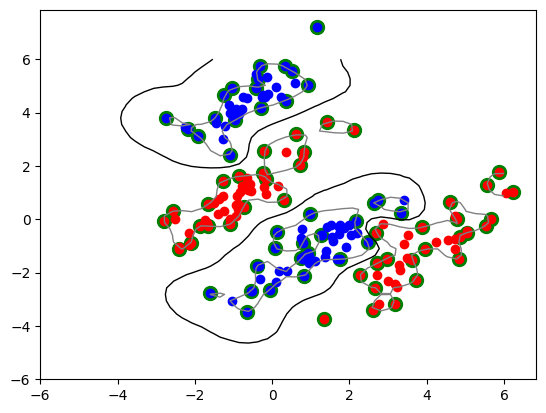

In [169]:
sigma = .5
C = 1000000
test_non_linear(gaussian_kernel, C)




*   малые значения C заставляют модель переобучиться
*   высокие делают её слишком грубой

